# task #3.1 randomized response for binary data
**based on**: Morris Chang, Di Zhuang, G. Dumindu Samaraweera - *Privacy-Preserving Machine Learning* (2023, Manning)

**dataset**: the titanic test file `aveshjadon/ai-impact-on-students`.

the book's example surveys people with the binary question "are you more than 50 years old?".
here we pick a binary question on the ai-impact-on-students dataset.
the `paid_subscription` column is already boolean (true/false), so it is a
natural yes/no survey question: "do you pay for a genai subscription?"


## import and understand dataset

In [1]:
import kagglehub

path = kagglehub.dataset_download("laveshjadon/ai-impact-on-students")
print("path to dataset files:", path)

Using Colab cache for faster access to the 'ai-impact-on-students' dataset.
path to dataset files: /kaggle/input/ai-impact-on-students


In [2]:
import os
files = os.listdir(path)
print("Files: ", files)

Files:  ['ai_student_impact_dataset (1).csv']


In [4]:
import pandas as pd
df = pd.read_csv(os.path.join(path, files[0]))

In [5]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [8]:
for i in df.columns.tolist():
  print("\nCOLUMN NAME\n", i, "\nDATA TYPE\n", df[i].dtype, "\nUNIQUE VALUES\n", df[i].unique(), "\nVALUE COUNTS\n", df[i].value_counts())
  print("________________________________________________")


COLUMN NAME
 Student_ID 
DATA TYPE
 int64 
UNIQUE VALUES
 [100001 100002 100003 ... 149998 149999 150000] 
VALUE COUNTS
 Student_ID
149984    1
149983    1
149982    1
149981    1
149980    1
         ..
100005    1
100004    1
100003    1
100002    1
100001    1
Name: count, Length: 50000, dtype: int64
________________________________________________

COLUMN NAME
 Major_Category 
DATA TYPE
 object 
UNIQUE VALUES
 ['Humanities' 'Medical' 'Business' 'STEM' 'Arts'] 
VALUE COUNTS
 Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64
________________________________________________

COLUMN NAME
 Year_of_Study 
DATA TYPE
 object 
UNIQUE VALUES
 ['Senior' 'Junior' 'Freshman' 'Sophomore' 'Graduate'] 
VALUE COUNTS
 Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64
________________________________________________

COLUMN NA

In [9]:
print(df["Paid_Subscription"].value_counts())

Paid_Subscription
False    28846
True     21154
Name: count, dtype: int64


In [10]:
import numpy as np

In [16]:
subs = df["Paid_Subscription"].astype(bool).values

total_count = len(subs)
true_yes_count = int(np.sum(subs))
print("Total count: ", total_count)
print("Total 'Yes': ", true_yes_count)
print("Total 'No' : ", total_count - true_yes_count)

Total count:  50000
Total 'Yes':  21154
Total 'No' :  28846


## listing 4.1 - randomized response-based algorithm
each individual flips two coins:
- first coin: if heads (0), return the true answer.
- second coin: otherwise return a random yes/no.

so they answer truthfully with prob 0.75 (1/2 + 1/4) and randomly the rest of the time. this gives ln(3)-local differential privacy.

In [17]:
def random_response_subscription(response):
    true_ans = bool(response)
    if np.random.randint(0, 2) == 0: # first flip
        return true_ans
    else:
        return np.random.randint(0, 2) == 0 # second flip

In [38]:
perturbed_yes_count = len([i for i in subs if random_response_subscription(i)])
print("Preturbed 'Yes': ", perturbed_yes_count, " | True 'Yes': ", true_yes_count)
print("Preturbed 'No' : ", total_count - perturbed_yes_count, " | True 'No' : ", total_count - true_yes_count)

Preturbed 'Yes':  23038  | True 'Yes':  21154
Preturbed 'No' :  26962  | True 'No' :  28846


## listing 4.4 - data aggregation and estimation
why the raw perturbed count is wrong, and how to correct it:
- a person gives a random answer with prob 0.5, and that random answer is "yes" with prob 0.5. so 0.5 * 0.5 = 0.25 of all responses are "false yesses" from pure randomness.
- the first coin splits people into a truth-telling group and a random group of roughly equal size, so the truthful yesses are about half the real total.
- therefore: real_yesses app.= (total_yesses - false_yesses) * 2

In [45]:
answers = [True if random_response_subscription(i) else False for i in subs]

def random_response_aggregation_and_estimation(answers):
    false_yesses = len(answers) / 4                         # app. 0.25 are false yesses from coin flips
    total_yesses = np.sum([1 if r else 0 for r in answers]) # total yesses received
    true_yesses = total_yesses - false_yesses               # remove the false yesses
    rr_result = true_yesses * 2                             # double -> estimate full population
    return rr_result

estimated_yes_count = random_response_aggregation_and_estimation(answers)
print("Estimated 'Yes': ", int(estimated_yes_count), " | True 'Yes': ", true_yes_count)
print("Estimated 'No' : ", total_count - int(estimated_yes_count), " | True 'No' : ", total_count - true_yes_count)

Estimated 'Yes':  21098  | True 'Yes':  21154
Estimated 'No' :  28902  | True 'No' :  28846


## visual comparison
real vs raw-perturbed vs corrected-estimate counts of "Yes".

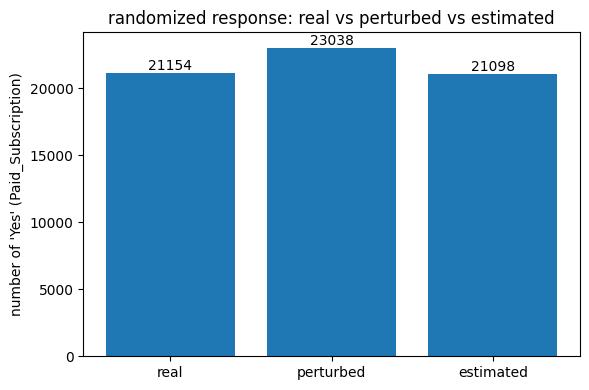

In [46]:
import matplotlib.pyplot as plt

labels = ["real", "perturbed", "estimated"]
values = [true_yes_count, perturbed_yes_count, int(estimated_yes_count)]

plt.figure(figsize=(6, 4))
plt.bar(labels, values)
plt.ylabel("number of 'Yes' (Paid_Subscription)")
plt.title("randomized response: real vs perturbed vs estimated")
for i, v in enumerate(values):
    plt.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()